<a href="https://colab.research.google.com/github/jlschwartz3/bio108tutorial/blob/main/Week3_Time_Series_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1: Time series data in Python

You will learn how to work with and plot time series data using the **pandas** package for **Python**.

We will learn how to work with the `datetime` object in
**Python** which you need for plotting and working with time series data.
You will also learn how to work with "no data" values in **Python**.

## Learning Objectives

After completing this chapter, you will be able to:

* Import a time series dataset using **pandas** with dates converted to a `datetime` object in **Python**.
* Use the `datetime` object to create easier-to-read time series plots and work with data across various timeframes (e.g. daily, monthly, yearly) in **Python**.
* Explain the role of "no data" values and how the `NaN` value is used in **Python** to label "no data" values.
* Set a "no data" value for a file when you import it into a **pandas** dataframe.

## Why Use Datetime Objects in Python

Dates can be tricky in any programming language. While you may
see a date in a dataset and recognize it as something that can
be quantified and related to time, a computer reads in numbers
and characters. Often by default, date information is loaded
as a string (i.e. a set of characters), rather than something
that has an order in time.

The **Python** `datetime` object will make working with and plotting
time series data easier. You can convert **pandas** dataframe
columns containing dates and times as strings into `datetime` objects.

Below, you will find a quick introduction to working with and
plotting time series data using Pandas. The following pages in
this chapter will dive further into the details associated with
using, manipulating and analyzing time series data.

### Import Packages and Get Data

To begin, import the packages that you need to work with tabular data in Python.  

```python
# Import necessary packages
from matplotlib.axes._axes import _log as matplotlib_axes_logger
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Handle date time conversions between pandas and matplotlib
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# Dealing with error thrown by one of the plots
matplotlib_axes_logger.setLevel('ERROR')
import warnings
warnings.filterwarnings('ignore')


# Adjust font size and style of all plots in notebook with seaborn
sns.set(font_scale=1.5, style="whitegrid")
```

```python
### Import the data
file_url = "https://figshare.com/ndownloader/files/7270970"
boulder_precip_2003_2013 = pd.read_csv(file_url)
boulder_precip_2003_2013.head()
```

In [ ]:
# Import necessary packages
from matplotlib.axes._axes import _log as matplotlib_axes_logger
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Handle date time conversions between pandas and matplotlib
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# Dealing with error thrown by one of the plots
matplotlib_axes_logger.setLevel('ERROR')
import warnings
warnings.filterwarnings('ignore')


# Adjust font size and style of all plots in notebook with seaborn
sns.set(font_scale=1.5, style="whitegrid")

### Import the data
file_url = "https://figshare.com/ndownloader/files/7270970"
boulder_precip_2003_2013 = pd.read_csv(file_url)
boulder_precip_2003_2013.head()

,STATION,STATION_NAME,ELEVATION,LATITUDE,LONGITUDE,DATE,HPCP,Measurement Flag,Quality Flag
0,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,20030101 01:00,0.0,g,
1,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,20030201 01:00,0.0,g,
2,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,20030202 19:00,0.2,,
3,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,20030202 22:00,0.1,,
4,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,20030203 02:00,0.1,,


Plot the data using the `DAILY_PRECIP` column. What do you notice about
the plot?

```python
boulder_precip_2003_2013.plot(x="DATE",
                              y="HPCP",
                              title="Daily Precipitation ")
plt.show()
```

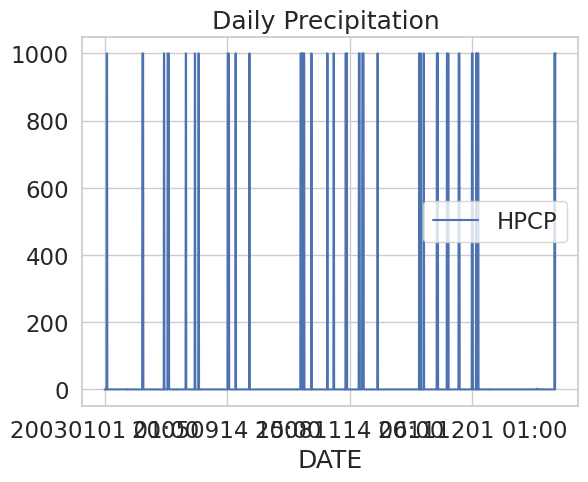

In [ ]:
boulder_precip_2003_2013.plot(x="DATE",
                              y="HPCP",
                              title="Daily Precipitation ")
plt.show()

### Challenge 1: Review Metadata

In the cell below list the things that you think look "wrong" with the plot
above.

**Next, read the [`PRECIP_HLY_documentation.pdf` metadata document](https://www.ncei.noaa.gov/pub/data/cdo/documentation/PRECIP_HLY_documentation.pdf) before answering items 1-4.**

1. Do the data have a no data value?
2. How are missing data "identified" in the table"?
3. How frequently are the data recorded (every second, minute, hour, day, week, etc?)?
4. What are the units of the data (NOTE - this may be a "trick" question :) ). But see what you can find in the metadata.

HINT: the next few cells may help you explore the data to better understand
what is going on with it.

The date values are confusing and overlapping, and the precipitation values are the same for every date and all near 1000.

1. No. Hours with no precipitation are just not shown.
2. They are entered as 99999.
3. Data are recorded every hour.
4. Units = hundredths of inches.

### Time Series Data Cleaning & Exploration

The data above do not look quite right. Take some time to explore the data to
better understand what you need to clean up.

```python
# Look at the range of values in the data - specifically the HPCP column
boulder_precip_2003_2013["HPCP"].describe()
```

```python
boulder_precip_2003_2013.dtypes
```

In [ ]:
# Look at the range of values in the data - specifically the HPCP column
boulder_precip_2003_2013["HPCP"].describe()

boulder_precip_2003_2013.dtypes

,0
STATION,object
STATION_NAME,object
ELEVATION,float64
LATITUDE,float64
LONGITUDE,float64
DATE,object
HPCP,float64
Measurement Flag,object
Quality Flag,object


You may have observed several anomalies in the data.

1. The data seem to have a very large number: 999.99. More often than note, a value of 999 represents a no data value that needs to be removed from your data.
2. You may have noticed that your x axis date values in the plot look "messy". When you see an x-axis like this but you know your data are time series, it's most often caused by your datetime data not being read in properly as numeric date times.

You can address all of these issues using the following `read_csv()` parameters:

* `parse_dates=`: Column containing date information that should be read into the `DataFrame` as a datetime object.
* `na_values=`: Values in the file that should be replaced with `NaN` (Not a Number).
* `index_col=1`: optional -- but this will make subsetting the data much easier

```python
# Import data using datetime and no data value
boulder_precip_2003_2013 = pd.read_csv(file_url,
                                       # Make sure the dates import in datetime format
                                       parse_dates=['DATE'],
                                       # Set DATE as the index so you can subset data by time period
                                       index_col=['DATE'],
                                       # Mask no data values so they are not plotted / used in analysis
                                       na_values=['999.99'])

# View the data
boulder_precip_2003_2013.head()
```

In [ ]:
# Import data using datetime and no data value
boulder_precip_2003_2013 = pd.read_csv(file_url,
                                       # Make sure the dates import in datetime format
                                       parse_dates=['DATE'],
                                       # Set DATE as the index so you can subset data by time period
                                       index_col=['DATE'],
                                       # Mask no data values so they are not plotted / used in analysis
                                       na_values=['999.99'])

# View the data
boulder_precip_2003_2013.head()

,STATION,STATION_NAME,ELEVATION,LATITUDE,LONGITUDE,HPCP,Measurement Flag,Quality Flag
DATE,,,,,,,,
2003-01-01 01:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,0.0,g,
2003-02-01 01:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,0.0,g,
2003-02-02 19:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,0.2,,
2003-02-02 22:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,0.1,,
2003-02-03 02:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,0.1,,


Notice above that the DATE column header is visually lower than the other
columns and the entire column is bold. This represents the DATE column as an
index. You set the DATE column as an index above using the parameter:

`index_col=['DATE']`

Once your date values are an index, you can more easily subset the data
by time period. You will learn how to do this below.

```python
# View summary statistics == Notice the DATE column is not included
boulder_precip_2003_2013.describe()
```

Notice that once you remove no data values, the min and max values for the HPCP column are more reasonable for hourly
precipitation ranging from 0 to 2.2.

In [ ]:
# View summary statistics == Notice the DATE column is not included
boulder_precip_2003_2013.describe()

,ELEVATION,LATITUDE,LONGITUDE,HPCP
count,1840.0,1840.000000,1840.000000,1746.000000
mean,1650.5,40.033851,-105.281106,0.111856
std,0.0,0.000045,0.000005,0.093222
min,1650.5,40.033800,-105.281110,0.000000
25%,1650.5,40.033800,-105.281110,0.100000
50%,1650.5,40.033890,-105.281110,0.100000
75%,1650.5,40.033890,-105.281100,0.100000
max,1650.5,40.033890,-105.281100,2.200000


### Using An Index In Pandas

Above, you used `index_col=['DATE']` to get the date column to be an index for
the Pandas DataFrame. Assigning an index column is helpful when using timeseries
data as it allows you to easily subset your data by time (see below for an
overview of subsetting data).

It is also important to know that once a column is an index, you need to call
it differently. For instance, below you run `.dtypes` on your data. Notice that
`DATE` is no longer a column described in your dataframe.

```python
# Where is the date column
boulder_precip_2003_2013.dtypes
```

You can still access the DATE column as an index column using `.index`:

`data-frame-name.index`

Try it out. Notice that below the output of `.index` is a `datetime64`
object.

```python
# View the index for your data frame
boulder_precip_2003_2013.index
```


In [ ]:
print(boulder_precip_2003_2013.dtypes)

boulder_precip_2003_2013.index

STATION              object
STATION_NAME         object
ELEVATION           float64
LATITUDE            float64
LONGITUDE           float64
HPCP                float64
Measurement Flag     object
Quality Flag         object
dtype: object


DatetimeIndex(['2003-01-01 01:00:00', '2003-02-01 01:00:00',
               '2003-02-02 19:00:00', '2003-02-02 22:00:00',
               '2003-02-03 02:00:00', '2003-02-05 02:00:00',
               '2003-02-05 08:00:00', '2003-02-06 00:00:00',
               '2003-02-07 12:00:00', '2003-02-10 13:00:00',
               ...
               '2013-12-01 01:00:00', '2013-12-03 20:00:00',
               '2013-12-04 03:00:00', '2013-12-04 06:00:00',
               '2013-12-04 09:00:00', '2013-12-22 01:00:00',
               '2013-12-23 00:00:00', '2013-12-23 02:00:00',
               '2013-12-29 01:00:00', '2013-12-31 00:00:00'],
              dtype='datetime64[ns]', name='DATE', length=1840, freq=None)

You can also reset the index if you want it to turn it back into a normal
column using `data-frame.reset_index()`

```python
boulder_precip_2003_2013.reset_index()
```


In [ ]:
boulder_precip_2003_2013.reset_index()

,DATE,STATION,STATION_NAME,ELEVATION,LATITUDE,LONGITUDE,HPCP,Measurement Flag,Quality Flag
0,2003-01-01 01:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,0.0,g,
1,2003-02-01 01:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,0.0,g,
2,2003-02-02 19:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,0.2,,
3,2003-02-02 22:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,0.1,,
4,2003-02-03 02:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,0.1,,
...,...,...,...,...,...,...,...,...,...
1835,2013-12-22 01:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.03380,-105.28110,NaN,[,
1836,2013-12-23 00:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.03380,-105.28110,NaN,],
1837,2013-12-23 02:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.03380,-105.28110,0.1,,
1838,2013-12-29 01:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.03380,-105.28110,NaN,[,


Now that you have cleaned up the data, you can plot it. Below, you use
`.plot()` to plot. If you have an index column, then `.plot()` will automatically
select that column to plot on the x-axis. You then only need to specify the
y-axis column.

```python
boulder_precip_2003_2013.plot(y="HPCP",
                              title="Hourly Precipitation")
plt.show()
```

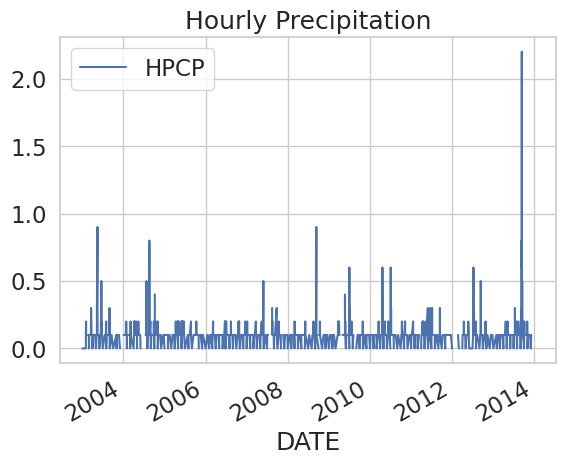

In [ ]:
boulder_precip_2003_2013.plot(y="HPCP",
                              title="Hourly Precipitation")
plt.show()

## Subset Time Series Data by Time

Once you have cleaned up your data, and assigned a datetime index,
you can quickly begin to plot and summarize
data by time periods. Below you subset the data for 2005.

```python
# Subset data from 2005
precip_2005 = boulder_precip_2003_2013.loc['2005']
precip_2005.head()
```

```python
# Remove missing data values
precip_2005_clean = precip_2005.dropna()
```

```python
# Plot the data using pandas

precip_2005_clean.reset_index().plot(x="DATE",
                                     y="HPCP",
                                     title="Hourly Precipitation",
                                     kind="scatter")
plt.show()
```

In [ ]:
# Subset data from 2005
precip_2005 = boulder_precip_2003_2013.loc['2005']
precip_2005.head()

,STATION,STATION_NAME,ELEVATION,LATITUDE,LONGITUDE,HPCP,Measurement Flag,Quality Flag
DATE,,,,,,,,
2005-01-01 01:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,0.0,g,
2005-01-02 06:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,NaN,{,
2005-01-02 08:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,NaN,},
2005-01-05 08:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,0.1,,
2005-01-12 04:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,0.1,,


                         STATION     STATION_NAME  ELEVATION  LATITUDE  \
DATE                                                                     
2005-01-01 01:00:00  COOP:050843  BOULDER 2 CO US     1650.5  40.03389   
2005-01-05 08:00:00  COOP:050843  BOULDER 2 CO US     1650.5  40.03389   
2005-01-12 04:00:00  COOP:050843  BOULDER 2 CO US     1650.5  40.03389   
2005-01-12 06:00:00  COOP:050843  BOULDER 2 CO US     1650.5  40.03389   
2005-01-12 08:00:00  COOP:050843  BOULDER 2 CO US     1650.5  40.03389   
...                          ...              ...        ...       ...   
2005-12-01 01:00:00  COOP:050843  BOULDER 2 CO US     1650.5  40.03389   
2005-12-03 00:00:00  COOP:050843  BOULDER 2 CO US     1650.5  40.03389   
2005-12-06 19:00:00  COOP:050843  BOULDER 2 CO US     1650.5  40.03389   
2005-12-07 01:00:00  COOP:050843  BOULDER 2 CO US     1650.5  40.03389   
2005-12-08 13:00:00  COOP:050843  BOULDER 2 CO US     1650.5  40.03389   

                     LONGITUDE  HPCP 

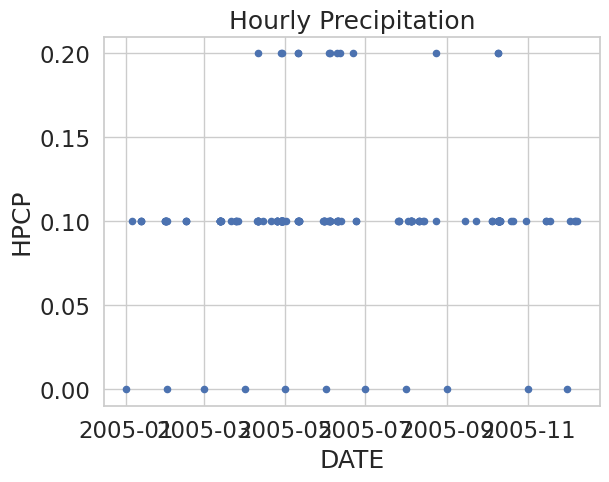

In [ ]:
# Remove missing data values
precip_2005_clean = precip_2005.dropna()
print(precip_2005_clean)

# Plot the data using pandas

precip_2005_clean.reset_index().plot(x="DATE",
                                     y="HPCP",
                                     title="Hourly Precipitation",
                                     kind="scatter")
plt.show()

While you can plot data with pandas, it's often easier to simply use a plotting library (e.g. matplotlib)
directly as this gives you more control of your plots. Below you create a scatter
plot of the data using `ax.scatter`.

```python
# Plot the data using native matplotlib
f, ax = plt.subplots()
ax.scatter(x=precip_2005_clean.index.values,
           y=precip_2005_clean["HPCP"])
plt.show()
```

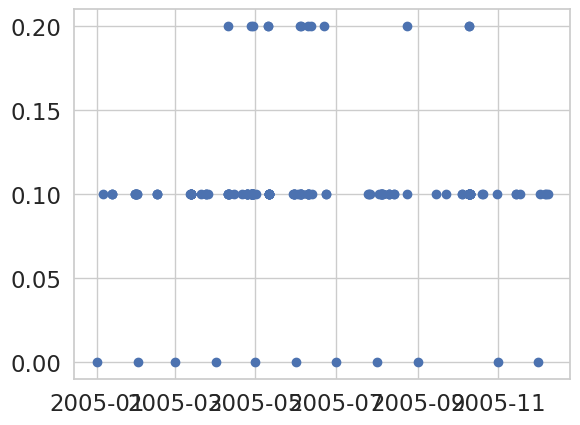

In [ ]:
# Plot the data using native matplotlib
f, ax = plt.subplots()
ax.scatter(x=precip_2005_clean.index.values,
           y=precip_2005_clean["HPCP"])
plt.show()

## Resample Time Series Data

Resampling time series data refers to the act of summarizing data
over different time periods. For example, above you have been working
with hourly data. However, you may want to plot data summarized by day.

You can resample time series data in Pandas using the `resample()`
method. Within that method you call the time frequency for which
you want to resample. Examples including day (`"D"`) or week `("w")`.

When you resample data, you need to also tell Python how you wish
to summarize the data for that time period. For example do you want
to summarize or add all all values for each day?

`precip_2005_clean.resample("D").sum()`

or do you want a max value:

`precip_2005_clean.resample("D").max()`

Below you resample the 2005 data subset that you created above, and
then you plot it. [Resampling is discussed in more detail later in this
chapter.](https://www.earthdatascience.org/courses/use-data-open-source-python/use-time-series-data-in-python/date-time-types-in-pandas-python/resample-time-series-data-pandas-python/)

```python
precip_2005_daily = precip_2005_clean.resample("D").sum()
# Plot the data using native matplotlib
f, ax = plt.subplots()
ax.scatter(x=precip_2005_daily.index.values,
           y=precip_2005_daily["HPCP"])
plt.show()
```


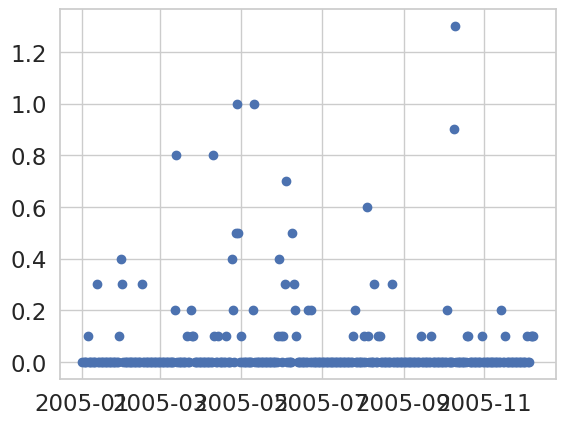

In [ ]:
precip_2005_daily = precip_2005_clean.resample("D").sum()
# Plot the data using native matplotlib
f, ax = plt.subplots()
ax.scatter(x=precip_2005_daily.index.values,
           y=precip_2005_daily["HPCP"])
plt.show()

## Plot Dates From Pandas Dataframe Using Datetime

In **matplotlib**, there are slight differences in how bar and scatter plots read in data versus how line plots read in data.

When plotting with `ax.bar()` and `ax.scatter()`, **numpy** is used to concatenate (a fancy word for combine) an array that has been created and passed in for the `x-axis` and/or `y-axis` data. However, **numpy** cannot concatenate the `datetime` object with other values.

Thus, if you try to pass a `datetime` column or index directly to `ax.bar()` or `ax.scatter()`, you will receive an error.


### Use Index Values Attribute to Plot Datetime

To avoid this error, you can call the attribute `.values` on the `datetime` index using:

`df.index.values`

Notice that here you use `df.index` to access the datetime column because you have assigned your date column to be an index for the dataframe.

Also, notice that the spacing on the x-axis looks better and that your x-axis date labels are easier to read, as **Python** knows how to only show incremental values using `datetime`, rather than plotting each and every date value.

**Note:** you do not need to use `.values` when using an index that contains `float` values, rather than `datetime` objects, nor when creating a line graph using `ax.plot()`.

However, for consistency of the code, the plot examples in this chapter will use `index.values` to create all plots using an index.

On later pages of this chapter, you will learn how to customize the date labels even more, such as displaying only month and day values or specifying the spacing for the time interval (i.e. frequency).

## Work With No Data Values in Pandas Dataframe

As mentioned previously, you likely noticed that there are many negative values in this dataset, which are actually "no data" values.

Sometimes data are missing from a file due to errors in collection, inability to record a data point, or other reasons. For example, imagine a spreadsheet with cells that are blank. If the cells are blank, you don't know for sure whether those data weren't collected, or whether someone forgot to fill them in.

To account for data that are missing (not by mistake), you can put a value into those cells that represents "no data" to make it clear that these data are not usable for analysis or plotting.

Often, you'll find a dataset that uses a specific value for "no data". In many scientific disciplines, the value `-999` is often used to indicate "no data" values.

If you do not specify that the value `-999` is the "no data" value, the values will be imported as real data, which will impact any statistics, calculations, and plots using the data.

For example, explore the data using `describe()` to see the impact of reading in those `-999` values as true values.

# 2: Subset time series data in Pandas

## Learning Objectives

* Subset time series data using different options for time frames, including by year, month, and with a specified begin and end date.

## Temporally Subset Data Using Pandas Dataframes

Sometimes a dataset contains a much larger timeframe than you need for your analysis or plot, and it can helpful to select, or subset, the data to the needed timeframe.

There are many ways to subset the data temporally in **Python**; one easy way to do this is to use **pandas**.

**Pandas** natively understands time operations if:
1. you tell it what column contains your time stamps (using the parameter `parse_dates`) and
2. you set the date column to be the index of the dataframe (using the parameter `index_col`).

On the previous page of this chapter, you already learned how to complete these steps during the `read_csv()` import into the **pandas** dataframe. On this page, you will learn how to use the `datetime` index to subset data from a **pandas dataframe**.

### Import Packages and Get Data

You will use a slightly modified version of precipitation data (inches) downloaded from the <a href="https://www.ncdc.noaa.gov/cdo-web/search" target ="_blank">National Centers for Environmental Information (formerly National Climate Data Center) Cooperative Observer Network (COOP)</a> station 050843 in Boulder, CO. The data were collected from January 1, 2003 through December 31, 2013.

Your instructor has modified these data as follows:
* aggregated the data to represent daily sum values.
* added some no data values to allow you to practice handling missing data.
* added new columns to this data that would not usually be there if you downloaded it directly:
    * Year
    * Julian day (i.e. the calendar day number)

To begin, import the necessary packages to work with **pandas** dataframe and download data.

You will continue to work with modules from **pandas** and **matplotlib** to plot dates more efficiently and with <a href="https://seaborn.pydata.org/introduction.html" target="_blank">**seaborn**</a> to make more attractive plots.  

```python
# Import necessary packages
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Handle date time conversions between pandas and matplotlib
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# Use white grid plot background from seaborn
sns.set(font_scale=1.5, style="whitegrid")
```

We will now explore subsetting time series data using a dataset from the NOAA PSL lab focused on flooding (aggregated to daily observations) in Boulder, CO.

You will import the file for the measurement station for Boulder, CO, and specify the:
1. no data values using the parameter `na_values`
2. date column using the parameter `parse_dates`
3. datetime index using the parameter `index_col`

```python
# Import data using datetime and no data value
file_url="https://figshare.com/ndownloader/files/7283285"
boulder_precip_2003_2013 = pd.read_csv(file_url,
                                       parse_dates=['DATE'],
                                       index_col= ['DATE'],
                                       na_values=['999.99'])

# View first few rows
boulder_precip_2003_2013.head()
```



In [ ]:
# Import necessary packages
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Handle date time conversions between pandas and matplotlib
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# Use white grid plot background from seaborn
sns.set(font_scale=1.5, style="whitegrid")

# Import data using datetime and no data value
file_url="https://figshare.com/ndownloader/files/7283285"
boulder_precip_2003_2013 = pd.read_csv(file_url,
                                       parse_dates=['DATE'],
                                       index_col= ['DATE'],
                                       na_values=['999.99'])

# View first few rows
boulder_precip_2003_2013.head()

,DAILY_PRECIP,STATION,STATION_NAME,ELEVATION,LATITUDE,LONGITUDE,YEAR,JULIAN
DATE,,,,,,,,
2003-01-01,0.0,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,2003,1
2003-01-05,NaN,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,2003,5
2003-02-01,0.0,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,2003,32
2003-02-02,NaN,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,2003,33
2003-02-03,0.4,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,2003,34


In [ ]:
boulder_precip_2003_2013.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 792 entries, 2003-01-01 to 2013-12-31
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   DAILY_PRECIP  788 non-null    float64
 1   STATION       792 non-null    object 
 2   STATION_NAME  792 non-null    object 
 3   ELEVATION     792 non-null    float64
 4   LATITUDE      792 non-null    float64
 5   LONGITUDE     792 non-null    float64
 6   YEAR          792 non-null    int64  
 7   JULIAN        792 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 55.7+ KB


### About the Precipitation Data

Viewing the structure of these data, you can see that different types of data are included in
this file.

* **STATION** and **STATION_NAME**: Identification of the COOP station.
* **ELEVATION, LATITUDE** and **LONGITUDE**: The spatial location of the station.
* **DAILY_PRECIP**: The total precipitation in inches. The metadata for this dataset notes that the value `999.99` indicates missing data. Also important, days with no precipitation are not included in the data.
* **YEAR**: the year the data were collected
* **JULIAN**: the JULIAN DAY the data were collected.

`DATE` is the date when the data were collected in the format: YYYY-MM-DD.

Notice that `DATE` is now the index value because you used the `parse_date` and `index_col` parameters when you imported the CSV file into a **pandas** dataframe.

Additional information about the data, known as metadata, is available in the
<a href="https://ndownloader.figshare.com/files/7283453">PRECIP_HLY_documentation.pdf</a>.

The metadata tell us that the no data value for these data is 999.99. IMPORTANT:
your instructor has modified these data a bit for ease of teaching and learning. Specifically,
data have been aggregated to represent daily sum values and some no data values have been added.

**Data Tip** You can download the original complete data subset with additional documentation
<a href="https://figshare.com/articles/NEON_Remote_Sensing_Boulder_Flood_2013_Teaching_Data_Subset_Lee_Hill_Road/3146284">here. </a>

Even after reading documentation, it is always a good idea to explore data before working with them such as:
1. checking out the data types
2. calculating the summary statistics to get a sense of the data values (and make sure that "no data" values have been identified)
3. checking out the values in the `datetime` index.

```python
# View dataframe info
boulder_precip_2003_2013.info()
```

```python
# View summary statistics
boulder_precip_2003_2013.describe()
```

```python
# View index values of dataframe
boulder_precip_2003_2013.index
```

In [ ]:
# View dataframe info
boulder_precip_2003_2013.info()
# View summary statistics
print(boulder_precip_2003_2013.describe())
# View index values of dataframe
boulder_precip_2003_2013.index

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 792 entries, 2003-01-01 to 2013-12-31
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   DAILY_PRECIP  788 non-null    float64
 1   STATION       792 non-null    object 
 2   STATION_NAME  792 non-null    object 
 3   ELEVATION     792 non-null    float64
 4   LATITUDE      792 non-null    float64
 5   LONGITUDE     792 non-null    float64
 6   YEAR          792 non-null    int64  
 7   JULIAN        792 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 55.7+ KB
       DAILY_PRECIP  ELEVATION    LATITUDE   LONGITUDE         YEAR  \
count    788.000000      792.0  792.000000  792.000000   792.000000   
mean       0.247843     1650.5   40.033850 -105.281106  2007.967172   
std        0.462558        0.0    0.000045    0.000005     3.149287   
min        0.000000     1650.5   40.033800 -105.281110  2003.000000   
25%        0.100000     1650.

DatetimeIndex(['2003-01-01', '2003-01-05', '2003-02-01', '2003-02-02',
               '2003-02-03', '2003-02-05', '2003-02-06', '2003-02-07',
               '2003-02-10', '2003-02-18',
               ...
               '2013-11-01', '2013-11-09', '2013-11-21', '2013-11-27',
               '2013-12-01', '2013-12-04', '2013-12-22', '2013-12-23',
               '2013-12-29', '2013-12-31'],
              dtype='datetime64[ns]', name='DATE', length=792, freq=None)

## Subset Pandas Dataframe By Year

Because you have a dataframe set up with an index, you can start to easily subset your data using the syntax:

`df["index_date"]`

Note that the `datetime` index value is accessed using quotation marks `""` similar to how you query for text strings.

Using this syntax, you can select all of the data for the year 2013 by specifying the value that you want to select from the `datetime` index:

```python
# Select 2013 data - view first few records
boulder_precip_2003_2013['2013'].head()
```

```python
# Select 2013 data - view last few records
boulder_precip_2003_2013['2013'].tail()
```

Note that in the previous example, you are querying the `datetime` index directly, not querying the values from the `Year` column.




## Subset Pandas Dataframe By Month

Using a `datetime` index with **pandas** makes it really easy to continue to select data using additional attributes of the index such as `month`.

This attribute of the `datetime` index can be accessed as:

`df.index.month == value`

where the month values are numeric values ranging from 1 to 12, representing January through December.

With this attribute, you can now employ the **pandas** syntax to <a href="{{ site.url }}/courses/intro-to-earth-data-science/scientific-data-structures-python/pandas-dataframes/indexing-filtering-data-pandas-dataframes/#filter-data-using-specific-values">filter values in a pandas dataframe</a> using the syntax:

`df[df.index.month == value]`

```python
# Select all December data - view first few rows
boulder_precip_2003_2013[boulder_precip_2003_2013.index.month == 12].head()
```

```python
# Select all December data - view last few rows
boulder_precip_2003_2013[boulder_precip_2003_2013.index.month == 12].tail()
```

Notice that `head()` displays December records in 2003, while `tail()` displays December records in 2013.

## Subset Pandas Dataframe By Day of Month

Similarly, you can the attribute `day` of the index to select all records for a specific day of the month as follows:

`df.index.month == value`

where the month values are numeric values ranging from 1 to 31, representing possible days of the month.

```python
# Select data for 1st of month - view first rows
boulder_precip_2003_2013[boulder_precip_2003_2013.index.day == 1]
```

## Subset Pandas Dataframe Using Range of Dates

You can also subset the data using a specific date range using the syntax:

`df["begin_index_date" : "end_index_date]`

For example, you can subset the data to a desired time period such as May 1, 2005 - August 31 2005, and then save it to a new dataframe.

```python
# Subset data to May-Aug 2005
precip_may_aug_2005 = boulder_precip_2003_2013['2005-05-01':'2005-08-31']

precip_may_aug_2005.head()
```


### Check Minimum and Maximum Values of Index

Rather than just checking the results of `head()` and `tail()`, you can actually query the `min` and `max` values of the index as follows:

```python
# Check min value of index
print(precip_may_aug_2005.index.min())

# Check max value of index
print(precip_may_aug_2005.index.max())
```

## Plot Temporal Subsets From Pandas Dataframe

Once you have subsetted the data and saved it, you can plot the data from the new dataframe to focus in on the desired time period.

Once again, you will use `.index.values` to access the `datetime` index values for the plot.

```python
# Create figure and plot space
fig, ax = plt.subplots(figsize=(10, 10))

# Add x-axis and y-axis
ax.bar(precip_may_aug_2005.index.values,
       precip_may_aug_2005['DAILY_PRECIP'],
       color='purple')

# Set title and labels for axes
ax.set(xlabel="Date",
       ylabel="Precipitation (inches)",
       title="Daily Total Precipitation\nMay - Aug 2005 for Boulder Creek")

# Rotate tick marks on x-axis
plt.setp(ax.get_xticklabels(), rotation=45)

plt.show()
```

### Think of New Applications and Uses of Subsetting

Given what you have learned about using `df.index.month` and `df.index.day` to select data by the month or day of the month value:
* What would you replace `month` or `day` with, in order to select data by year or even a specific week of the year?


## Homework: Putting it all together

This week, your homework will be to:

* Navigate to a data repository (e.g. Dryad, Figshare, the Harvard Dataverse) and download a *time series* dataset
* I expect that you will also read the metadata for these data, and if there is a peer-reviewed publication associated with the data, read the abstract, methods, and results. You can skim the Introduction and Discussion.
* You will import these data into Python and perform initial cleaning and manipulation operations.
* You will perform at least one subsetting analysis and generate two different plots.
* Your examination of the dataset should guide your choices in how you process, subset, and plot the data.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from matplotlib.axes._axes import _log as matplotlib_axes_logger
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Handle date time conversions between pandas and matplotlib
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# Dealing with error thrown by one of the plots
matplotlib_axes_logger.setLevel('ERROR')
import warnings
warnings.filterwarnings('ignore')


# Adjust font size and style of all plots in notebook with seaborn
sns.set(font_scale=1.5, style="whitegrid")

### Import the data
file_url = "/content/drive/MyDrive/BIO 109 Data Science/samples_2019-05-08.csv"
data = pd.read_csv(file_url)
data.head()

,year,date_sampled,site,block,doy,times_sampled,habitat_type,bowls_down,bowls_up,bowl_time,...,am_netters,start_pm,pm_nettime_hrs,pm_netters,total_time,high_temp,wind,cloud_cover,precip,notes
0,2009,22-Jun,Willey,A,173,1.0,Willow,8:58,17:50,8:52,...,"J. Welch, R. Diaz, R. Irwin",17:42,1.00,"J. Welch, R. Diaz",2.00,NaN,NaN,NaN,NaN,NaN
1,2009,22-Jun,Tuttle,A,173,1.0,Veratrum,9:25,17:16,7:51,...,"J. Welch, R. Diaz",16:33,1.00,"J. Welch, R. Diaz",2.00,NaN,NaN,NaN,NaN,NaN
2,2009,22-Jun,Davids,A,173,1.0,Dry,10:11,16:15,6:04,...,"J. Welch, R. Diaz, R. Irwin",14:54,1.00,"J. Welch, R. Diaz",2.00,22,1 SW,0.0,0.0,NaN
3,2009,01-Jul,Gothic,B,182,1.0,Willow,9:05,14:40,5:35,...,"J. Welch, P. Howel",13:20,1.00,J. Welch,2.00,NaN,NaN,NaN,NaN,NaN
4,2009,01-Jul,Beaver,B,182,1.0,Veratrum,9:51,15:46,5:55,...,"J. Welch, P. Howel",14:48,0.67,J. Welch,1.67,NaN,NaN,NaN,NaN,NaN


In [ ]:
data = pd.read_csv(file_url,
                   parse_dates=['year'],
                   index_col=['year'],
                   na_values=['999.99'])

# View the data
data.head()
#this is not quite right... year is showing wrong month and day


,date_sampled,site,block,doy,times_sampled,habitat_type,bowls_down,bowls_up,bowl_time,start_am,...,am_netters,start_pm,pm_nettime_hrs,pm_netters,total_time,high_temp,wind,cloud_cover,precip,notes
year,,,,,,,,,,,,,,,,,,,,,
2009-01-01,22-Jun,Willey,A,173,1.0,Willow,8:58,17:50,8:52,12:54,...,"J. Welch, R. Diaz, R. Irwin",17:42,1.00,"J. Welch, R. Diaz",2.00,NaN,NaN,NaN,NaN,NaN
2009-01-01,22-Jun,Tuttle,A,173,1.0,Veratrum,9:25,17:16,7:51,11:11,...,"J. Welch, R. Diaz",16:33,1.00,"J. Welch, R. Diaz",2.00,NaN,NaN,NaN,NaN,NaN
2009-01-01,22-Jun,Davids,A,173,1.0,Dry,10:11,16:15,6:04,10:21,...,"J. Welch, R. Diaz, R. Irwin",14:54,1.00,"J. Welch, R. Diaz",2.00,22,1 SW,0.0,0.0,NaN
2009-01-01,01-Jul,Gothic,B,182,1.0,Willow,9:05,14:40,5:35,8:47,...,"J. Welch, P. Howel",13:20,1.00,J. Welch,2.00,NaN,NaN,NaN,NaN,NaN
2009-01-01,01-Jul,Beaver,B,182,1.0,Veratrum,9:51,15:46,5:55,9:34,...,"J. Welch, P. Howel",14:48,0.67,J. Welch,1.67,NaN,NaN,NaN,NaN,NaN


In [ ]:
import pandas as pd # I experimented with some code I found on stack overflow to combine the date/months and year columns into one single column
# to make into a datetime object, but I'm not sure if it's right

data = pd.read_csv(file_url,
                   # Mask no-data values
                   na_values=['999.99'])

data['date'] = data['date_sampled'] + '-' + data['year'].astype(str)
data['date'] = pd.to_datetime(data['date'], format='%d-%b-%Y')

# indexing date
data.set_index('date', inplace=True)

data.head()


,year,date_sampled,site,block,doy,times_sampled,habitat_type,bowls_down,bowls_up,bowl_time,...,am_netters,start_pm,pm_nettime_hrs,pm_netters,total_time,high_temp,wind,cloud_cover,precip,notes
date,,,,,,,,,,,,,,,,,,,,,
2009-06-22,2009,22-Jun,Willey,A,173,1.0,Willow,8:58,17:50,8:52,...,"J. Welch, R. Diaz, R. Irwin",17:42,1.00,"J. Welch, R. Diaz",2.00,NaN,NaN,NaN,NaN,NaN
2009-06-22,2009,22-Jun,Tuttle,A,173,1.0,Veratrum,9:25,17:16,7:51,...,"J. Welch, R. Diaz",16:33,1.00,"J. Welch, R. Diaz",2.00,NaN,NaN,NaN,NaN,NaN
2009-06-22,2009,22-Jun,Davids,A,173,1.0,Dry,10:11,16:15,6:04,...,"J. Welch, R. Diaz, R. Irwin",14:54,1.00,"J. Welch, R. Diaz",2.00,22,1 SW,0.0,0.0,NaN
2009-07-01,2009,01-Jul,Gothic,B,182,1.0,Willow,9:05,14:40,5:35,...,"J. Welch, P. Howel",13:20,1.00,J. Welch,2.00,NaN,NaN,NaN,NaN,NaN
2009-07-01,2009,01-Jul,Beaver,B,182,1.0,Veratrum,9:51,15:46,5:55,...,"J. Welch, P. Howel",14:48,0.67,J. Welch,1.67,NaN,NaN,NaN,NaN,NaN


In [ ]:
data.describe()

,doy,times_sampled,am_nettime_hrs,pm_nettime_hrs,total_time,cloud_cover,precip
count,921.000000,799.000000,918.000000,906.000000,918.000000,17.000000,17.000000
mean,194.207383,3.710889,0.980225,0.866188,1.835091,1.176471,0.020000
std,30.760601,2.064807,0.119450,0.321676,0.361602,1.185079,0.053033
min,108.000000,0.000000,0.000000,0.000000,0.166666,0.000000,0.000000
25%,170.000000,2.000000,1.000000,1.000000,2.000000,0.000000,0.000000
50%,196.000000,4.000000,1.000000,1.000000,2.000000,1.000000,0.000000
75%,220.000000,5.000000,1.000000,1.000000,2.000000,2.000000,0.000000
max,257.000000,9.000000,1.170000,1.080000,2.250000,4.000000,0.170000


In [ ]:
data.dtypes

,0
date_sampled,object
site,object
block,object
doy,int64
times_sampled,float64
habitat_type,object
bowls_down,object
bowls_up,object
bowl_time,object
start_am,object


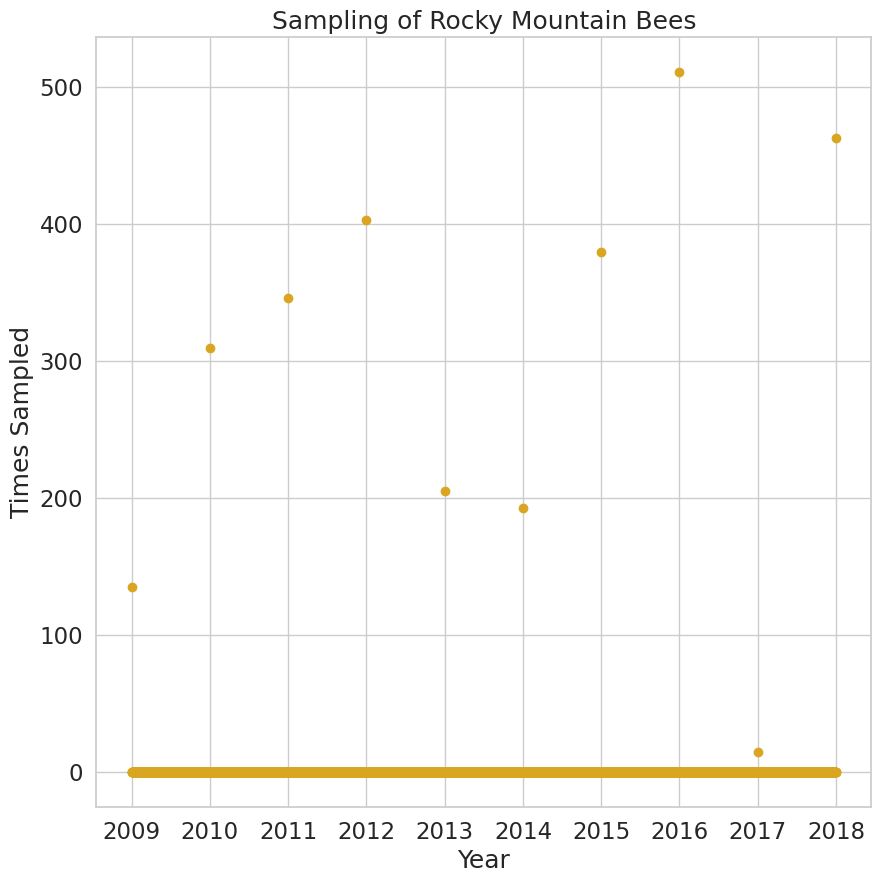

In [ ]:
# plot 1
data = data.dropna(subset=['times_sampled'])
data_resample = data.resample("D").sum()

fig, ax = plt.subplots(figsize=(10, 10))


ax.scatter(data_resample.index.values,
           data_resample['times_sampled'],
           color='goldenrod')

ax.set(xlabel="Year",
       ylabel="Times Sampled",
       title="Sampling of Rocky Mountain Bees")

plt.show()

In [ ]:
data = pd.read_csv(file_url,
                   # Mask no-data values
                   na_values=['999.99'])

data['date'] = data['date_sampled'] + '-' + data['year'].astype(str)
data['date'] = pd.to_datetime(data['date'], format='%d-%b-%Y')

# indexing date
data.set_index('date', inplace=True)

data.head()

data_2016= data['2016-01-01':'2016-12-31']

data_2016.head()

,year,date_sampled,site,block,doy,times_sampled,habitat_type,bowls_down,bowls_up,bowl_time,...,am_netters,start_pm,pm_nettime_hrs,pm_netters,total_time,high_temp,wind,cloud_cover,precip,notes
date,,,,,,,,,,,,,,,,,,,,,
2016-05-04,2016,04-May,Almont,Weather station,125,1.0,Weather station,9:52,15:50,5:58,...,G. Pardee,14:51,1.0,"G. Pardee, S. Griffin",2.0,NaN,NaN,NaN,NaN,NaN
2016-05-04,2016,04-May,Almont Curve,Elevation transect,125,1.0,Elevation transect,9:16,15:52,6:36,...,"G. Pardee, S. Griffin",16:19,1.0,"G. Pardee, S. Griffin",2.0,NaN,NaN,NaN,NaN,NaN
2016-05-05,2016,05-May,Lypps,Elevation transect,126,1.0,Elevation transect,9:30,16:07,6:37,...,"G. Pardee, S. Griffin",14:00,1.0,"G. Pardee, S. Griffin",2.0,NaN,NaN,NaN,NaN,NaN
2016-05-05,2016,05-May,CDOT,Elevation transect,126,1.0,Elevation transect,9:00,15:35,6:35,...,"G. Pardee, S. Griffin",15:02,1.0,"G. Pardee, S. Griffin",2.0,NaN,NaN,NaN,NaN,NaN
2016-05-21,2016,21-May,Almont,Weather station,142,2.0,Weather station,9:32,17:16,7:44,...,S. Griffin,14:12,1.0,S. Griffin,2.0,NaN,NaN,NaN,NaN,NaN


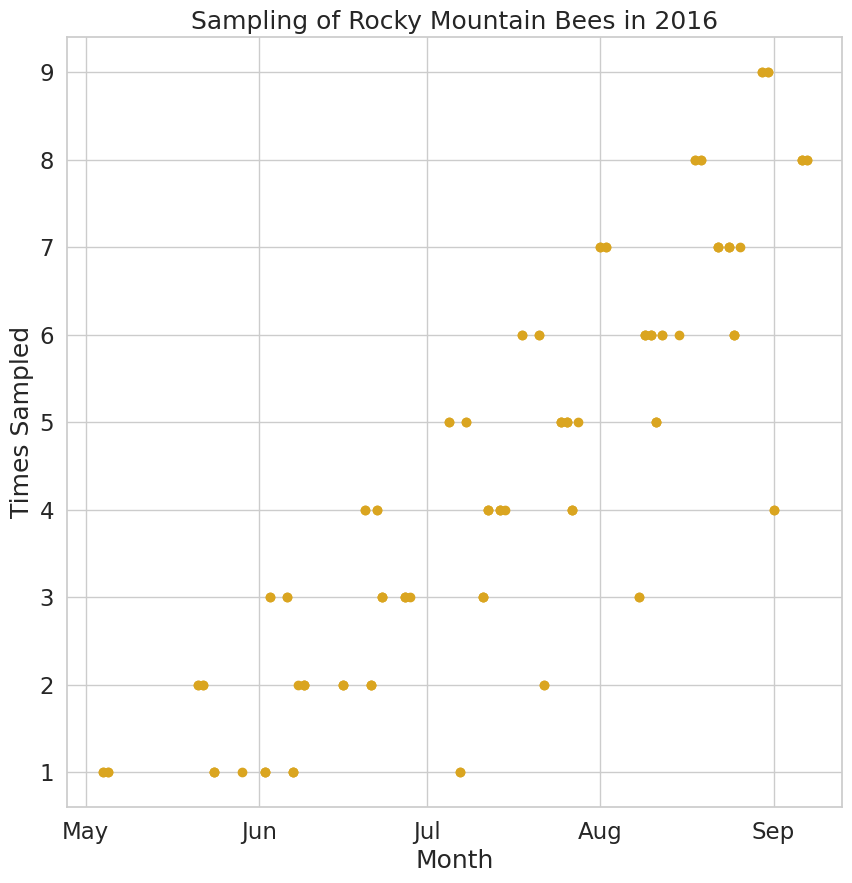

In [ ]:
from matplotlib.dates import DateFormatter, MonthLocator
fig, ax = plt.subplots(figsize=(10, 10))

# Axes
ax.scatter(data_2016.index.values,
           data_2016['times_sampled'],
           color='goldenrod')

# Labels
ax.set(xlabel="Month",
       ylabel="Times Sampled",
       title="Sampling of Rocky Mountain Bees in 2016")

ax.xaxis.set_major_locator(MonthLocator())
ax.xaxis.set_major_formatter(DateFormatter("%b"))

plt.show()


In [ ]:
print(data_2016.index.min(), data_2016.index.max())  # Check min/max dates
print(data_2016.index.unique())  # See all unique dates


2016-01-01 00:00:00 2016-01-01 00:00:00
DatetimeIndex(['2016-01-01'], dtype='datetime64[ns]', name='year', freq=None)
